##Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings

Setup and Environment configuration

In [2]:

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#dddddd'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {
    'primary': '#1d3557',   
    'secondary': '#457b9d',   
    'accent': '#e63946',      
    'light': '#f1faee',       
    'highlight': '#a8dadc'    
}
sns.set_palette([PALETTE['primary'], PALETTE['secondary'], PALETTE['highlight'], PALETTE['accent']])

print("Environment successfully configured with custom visualization style.")

Environment successfully configured with custom visualization style.


In [3]:
import os
print(os.getcwd())

c:\insurance-risk-analytics\notebooks


Load the data

In [4]:
df = pd.read_csv("C:\\MachineLearningRating_v3.txt", sep="|", encoding="utf-8")

In [107]:
print(df.head())
print(df.shape)
print(df.info())

   UnderwrittenCoverID  PolicyID TransactionMonth IsVATRegistered Citizenship  \
0               145249     12827       2015-03-01            True               
1               145249     12827       2015-05-01            True               
2               145249     12827       2015-07-01            True               
3               145255     12827       2015-05-01            True               
4               145255     12827       2015-07-01            True               

           LegalType Title Language                 Bank      AccountType  \
0  Close Corporation    Mr  English  First National Bank  Current account   
1  Close Corporation    Mr  English  First National Bank  Current account   
2  Close Corporation    Mr  English  First National Bank  Current account   
3  Close Corporation    Mr  English  First National Bank  Current account   
4  Close Corporation    Mr  English  First National Bank  Current account   

   ... ExcessSelected CoverCategory   CoverType   

Identify Columun Groups 

In [108]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "category", "string"]).columns
datetime_cols = df.select_dtypes(include=["datetime64[ns]"]).columns

Review Data Type

In [109]:
# Display data types
print(df.dtypes)

UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[us]
IsVATRegistered                   category
Citizenship                       category
LegalType                         category
Title                             category
Language                          category
Bank                              category
AccountType                       category
MaritalStatus                     category
Gender                            category
Country                           category
Province                          category
PostalCode                           int64
MainCrestaZone                         str
SubCrestaZone                          str
ItemType                               str
mmcode                             float64
VehicleType                       category
RegistrationYear                     int64
make                              category
Model                             category
Cylinders  

Correct Data Types

In [110]:
df['TransactionMonth'] = pd.to_datetime(
    df['TransactionMonth'],
    errors='coerce'
)

df['VehicleIntroDate'] = pd.to_datetime(
    df['VehicleIntroDate'],
    errors='coerce'
)

Convert The Categorical categories

In [111]:
categorical_cols = [
    'IsVATRegistered',
    'Citizenship',
    'LegalType',
    'Title',
    'Language',
    'Bank',
    'AccountType',
    'MaritalStatus',
    'Gender',
    'Country',
    'Province',
    'VehicleType',
    'make',
    'Model',
    'bodytype',
    'AlarmImmobiliser',
    'TrackingDevice',
    'NewVehicle',
    'WrittenOff',
    'Rebuilt',
    'Converted',
    'CrossBorder',
    'TermFrequency',
    'CoverCategory',
    'CoverType',
    'CoverGroup',
    'Section',
    'Product',
    'StatutoryClass',
    'StatutoryRiskType'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

Ensure numerical columuns are numerical

In [112]:
numerical_cols = [
    'RegistrationYear',
    'Cylinders',
    'cubiccapacity',
    'kilowatts',
    'NumberOfDoors',
    'CustomValueEstimate',
    'CapitalOutstanding',
    'NumberOfVehiclesInFleet',
    'SumInsured',
    'CalculatedPremiumPerTerm',
    'ExcessSelected',
    'TotalPremium',
    'TotalClaims'
]

for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

confirm Updated data types

In [113]:
print(df.dtypes)

UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[us]
IsVATRegistered                   category
Citizenship                       category
LegalType                         category
Title                             category
Language                          category
Bank                              category
AccountType                       category
MaritalStatus                     category
Gender                            category
Country                           category
Province                          category
PostalCode                           int64
MainCrestaZone                         str
SubCrestaZone                          str
ItemType                               str
mmcode                             float64
VehicleType                       category
RegistrationYear                     int64
make                              category
Model                             category
Cylinders  

Discriptive statistics for numerical Features

In [114]:
summary_stats = df[numerical_cols].describe().T

print(summary_stats)

                              count           mean           std  \
RegistrationYear          1000098.0    2010.225371  3.261391e+00   
Cylinders                  999546.0       4.046642  2.940201e-01   
cubiccapacity              999546.0    2466.743258  4.428006e+02   
kilowatts                  999546.0      97.207919  1.939326e+01   
NumberOfDoors              999546.0       4.019250  4.683144e-01   
CustomValueEstimate        220456.0  225531.129942  5.645157e+05   
CapitalOutstanding         999776.0   52605.220796  1.114172e+05   
NumberOfVehiclesInFleet         0.0            NaN           NaN   
SumInsured                1000098.0  604172.732589  1.508332e+06   
CalculatedPremiumPerTerm  1000098.0     117.875691  3.997017e+02   
ExcessSelected                  0.0            NaN           NaN   
TotalPremium              1000098.0      61.905496  2.302845e+02   
TotalClaims               1000098.0      64.861190  2.384075e+03   

                                   min         

Additional statistics measures

In [115]:
additional_stats = pd.DataFrame({
    'MissingValues': df[numerical_cols].isnull().sum(),
    'MissingPercentage': df[numerical_cols].isnull().mean() * 100,
    'Variance': df[numerical_cols].var(),
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurtosis()
})

print(additional_stats)

                          MissingValues  MissingPercentage      Variance  \
RegistrationYear                      0           0.000000  1.063667e+01   
Cylinders                           552           0.055195  8.644783e-02   
cubiccapacity                       552           0.055195  1.960724e+05   
kilowatts                           552           0.055195  3.760984e+02   
NumberOfDoors                       552           0.055195  2.193184e-01   
CustomValueEstimate              779642          77.956560  3.186780e+11   
CapitalOutstanding                  322           0.032197  1.241379e+10   
NumberOfVehiclesInFleet         1000098         100.000000           NaN   
SumInsured                            0           0.000000  2.275065e+12   
CalculatedPremiumPerTerm              0           0.000000  1.597615e+05   
ExcessSelected                  1000098         100.000000           NaN   
TotalPremium                          0           0.000000  5.303096e+04   
TotalClaims 

focused variable analysis

TotalPremium

In [116]:
print(df['TotalPremium'].describe())

count    1.000098e+06
mean     6.190550e+01
std      2.302845e+02
min     -7.825768e+02
25%      0.000000e+00
50%      2.178333e+00
75%      2.192982e+01
max      6.528260e+04
Name: TotalPremium, dtype: float64


TotalClaims

In [117]:
print(df['TotalClaims'].describe())

count    1.000098e+06
mean     6.486119e+01
std      2.384075e+03
min     -1.200241e+04
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.930921e+05
Name: TotalClaims, dtype: float64


SumInsured

In [118]:
print(df['SumInsured'].describe())

count    1.000098e+06
mean     6.041727e+05
std      1.508332e+06
min      1.000000e-02
25%      5.000000e+03
50%      7.500000e+03
75%      2.500000e+05
max      1.263620e+07
Name: SumInsured, dtype: float64


Checking Missing Values 

In [119]:
# Count missing values
missing_count = df.isnull().sum()

# Percentage missing
missing_percentage = (
    df.isnull().mean() * 100
)

# Combine into summary table
missing_summary = pd.DataFrame({
    'MissingCount': missing_count,
    'MissingPercentage': missing_percentage
})

# Filter only columns with missing values
missing_summary = missing_summary[
    missing_summary['MissingCount'] > 0
]

# Sort descending
missing_summary = missing_summary.sort_values(
    by='MissingPercentage',
    ascending=False
)

print(missing_summary)

                         MissingCount  MissingPercentage
ExcessSelected                1000098         100.000000
NumberOfVehiclesInFleet       1000098         100.000000
CrossBorder                    999400          99.930207
CustomValueEstimate            779642          77.956560
Converted                      641901          64.183810
WrittenOff                     641901          64.183810
Rebuilt                        641901          64.183810
NewVehicle                     153295          15.327998
Bank                           145961          14.594670
AccountType                     40232           4.022806
Gender                           9536           0.953507
MaritalStatus                    8259           0.825819
make                              552           0.055195
mmcode                            552           0.055195
VehicleType                       552           0.055195
VehicleIntroDate                  552           0.055195
NumberOfDoors                  

Visualize the missing value

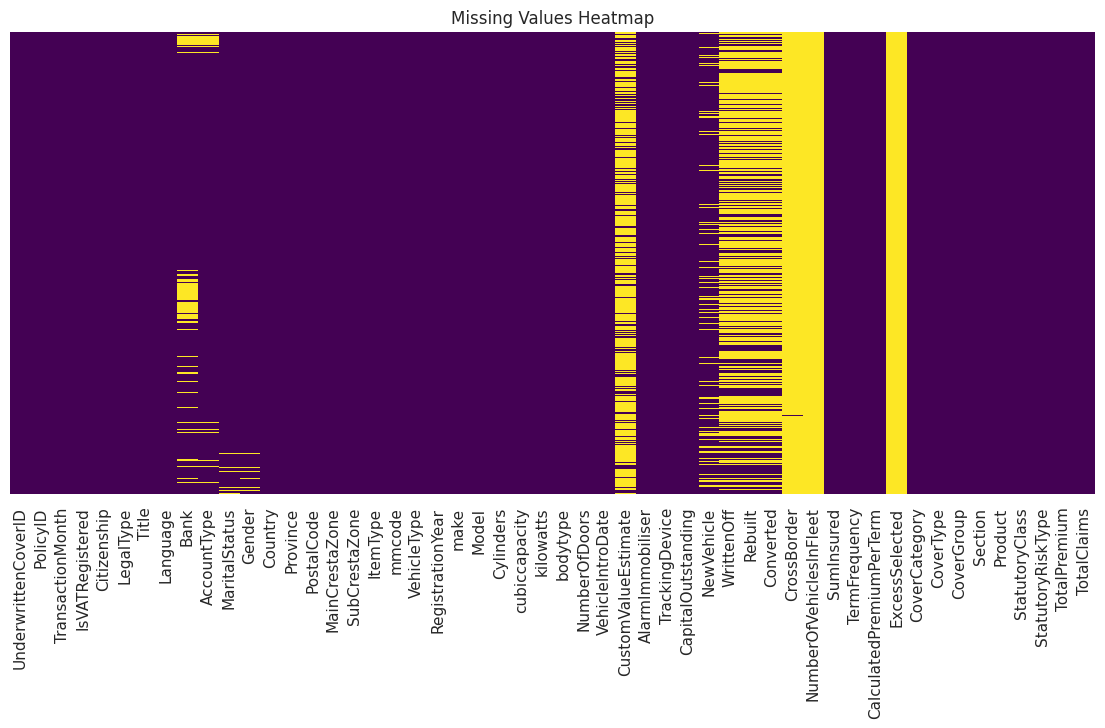

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")
plt.show()

Missing Value Handling Strategy
A. Numerical Columns
Recommended Strategy
Scenario	                            Handling Method
Small missingness                     	Median imputation
Highly skewed data	                    Median preferred
Approximately normal	                Mean imputation
Critical business feature	            Investigate before imputation

In [121]:
for col in numerical_cols:
    df[col].fillna(
        df[col].median(),
        inplace=True
    )

Categorical Columns
Recommended Strategy

Scenario	                         Handling Method
Small missingness	                 Mode imputation
Unknown category meaningful          Create "Unknown"
Many missing values	                 Group into new category

In [122]:
for col in categorical_cols:
    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

detect duplicate records

In [123]:
# Number of duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


check invalid values
##Question: does the negative value when doing the variable analysis for TotalPremium indicates the anomalies or refunds/cancellation?

In [124]:
##invalid_premium = df[df['TotalPremium'] < 0]
##invalid_claims = df[df['TotalClaims'] < 0]

##print("Invalid Premiums:", len(invalid_premium))
##print("Invalid Claims:", len(invalid_claims))

Unrealistic Vehicle years

In [125]:
invalid_years = df[
    (df['RegistrationYear'] < 1900) |
    (df['RegistrationYear'] > 2026)
]

print(invalid_years.shape)

(0, 52)


### Univariant Analysis

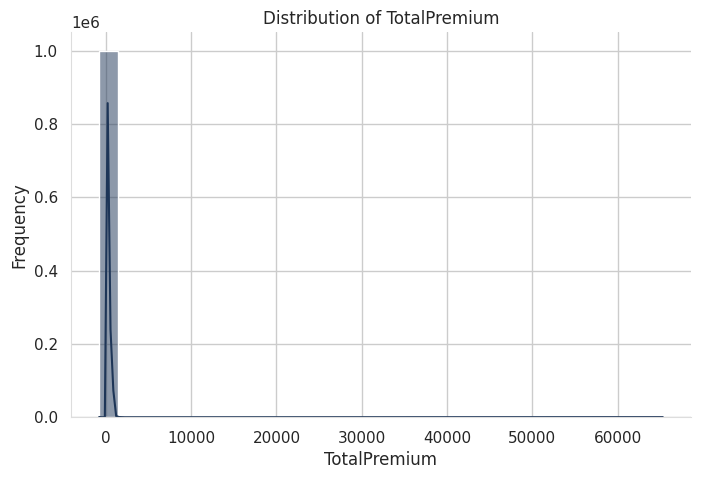

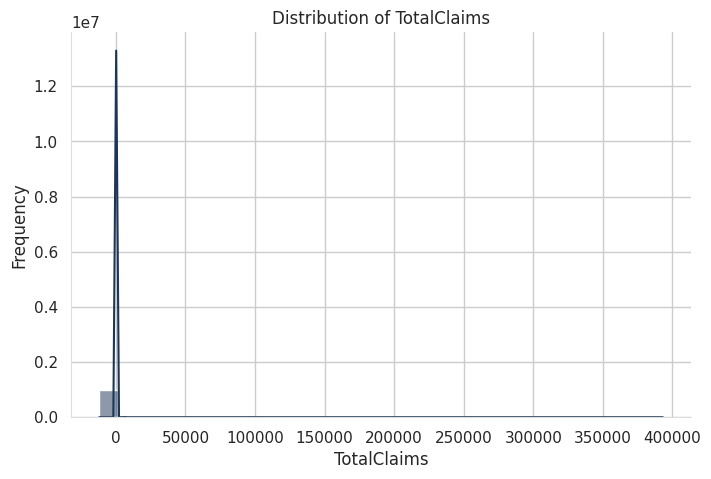

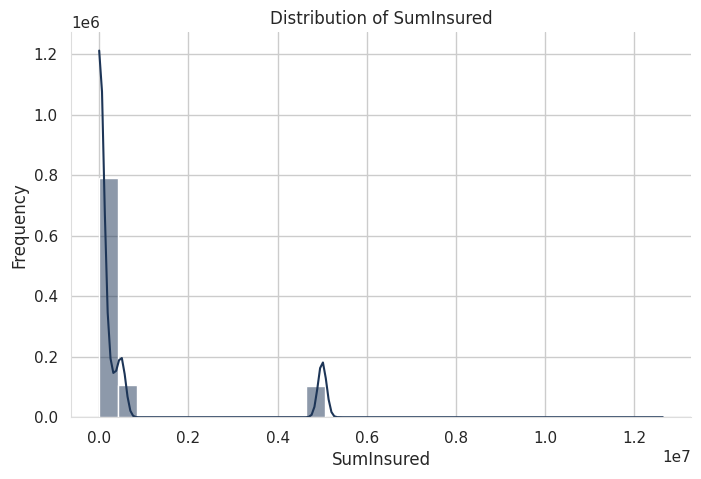

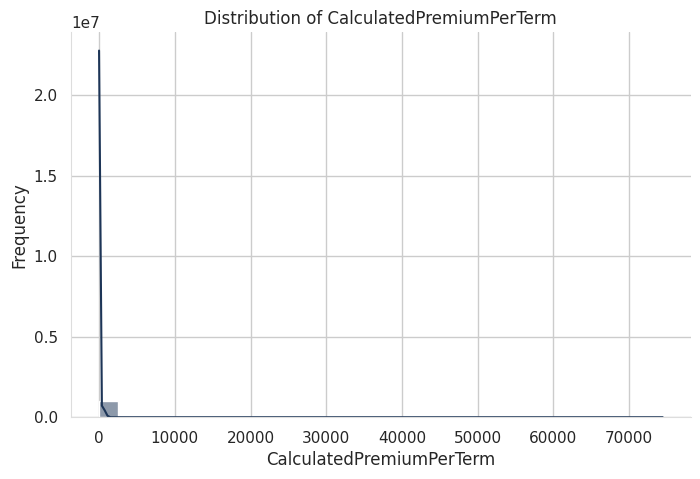

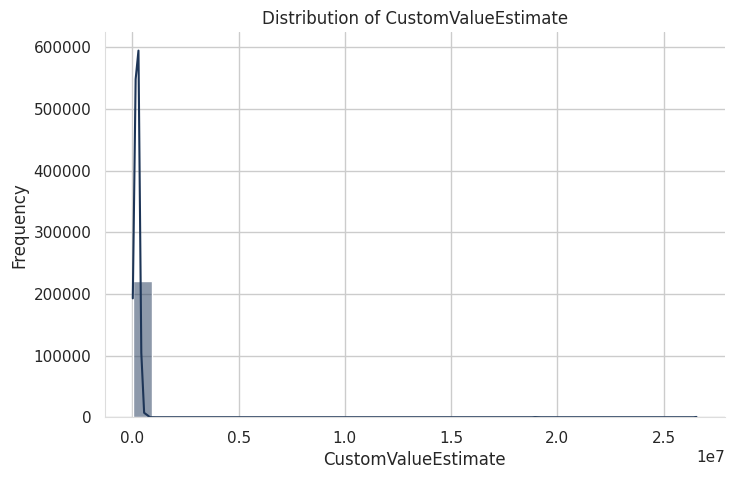

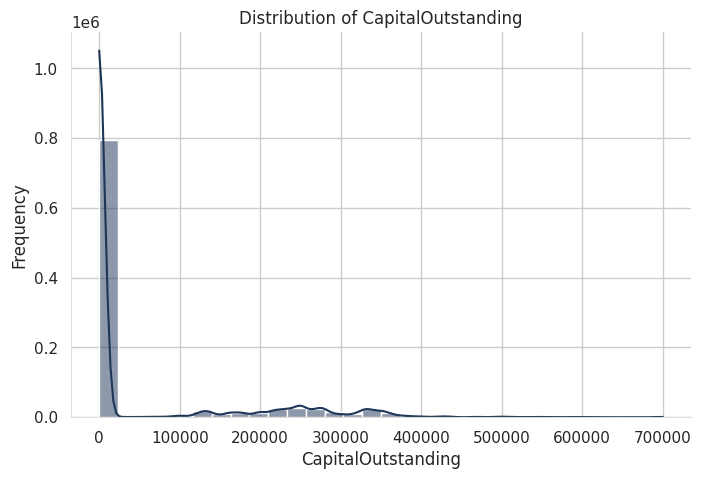

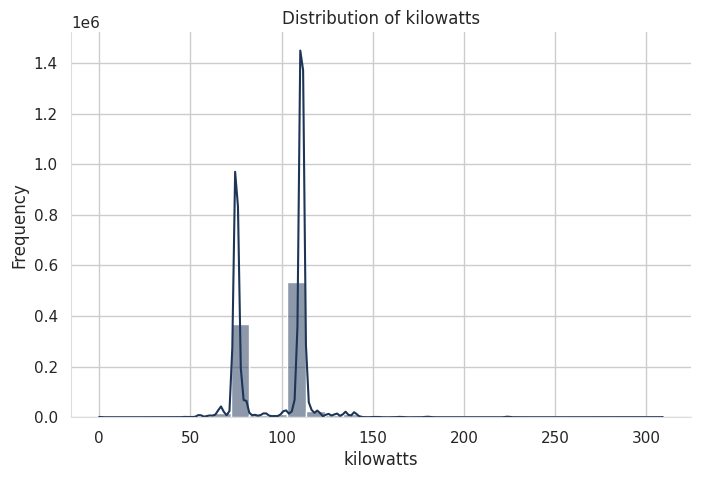

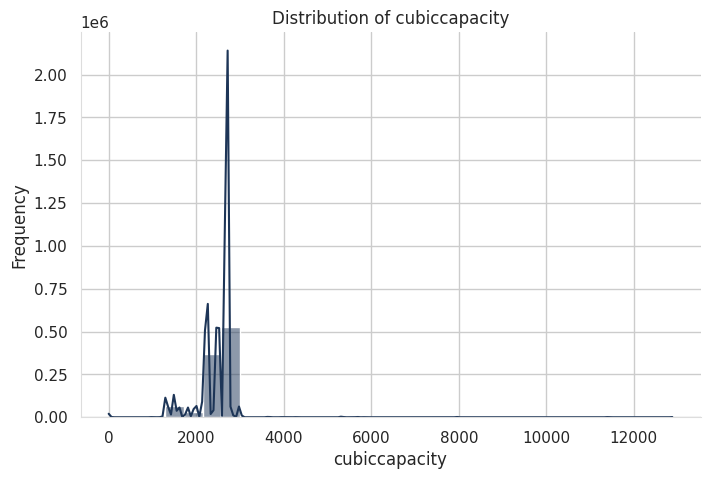

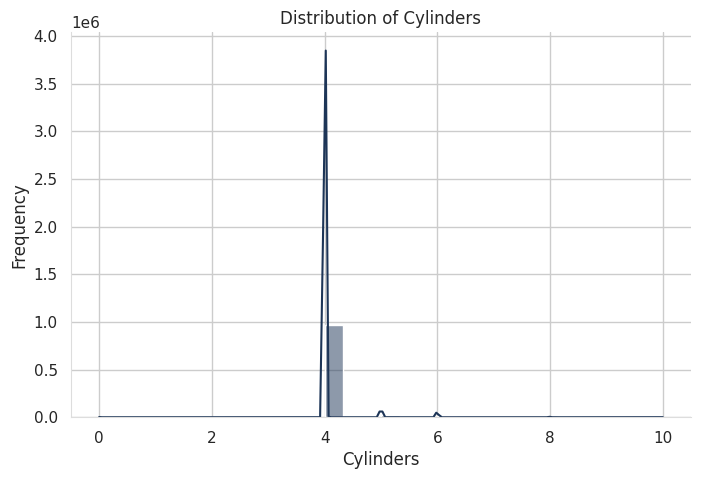

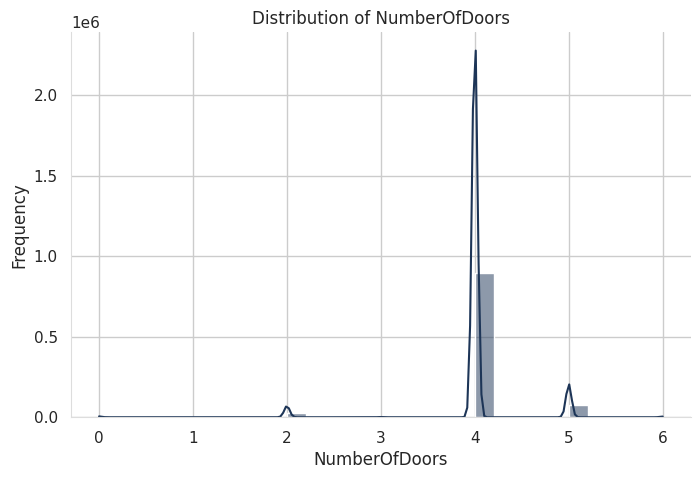

In [126]:
numerical_cols = [
    'TotalPremium',
    'TotalClaims',
    'SumInsured',
    'CalculatedPremiumPerTerm',
    'CustomValueEstimate',
    'CapitalOutstanding',
    'kilowatts',
    'cubiccapacity',
    'Cylinders',
    'NumberOfDoors'
]
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        bins=30,
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()

## Bar Charts for Categorical Features

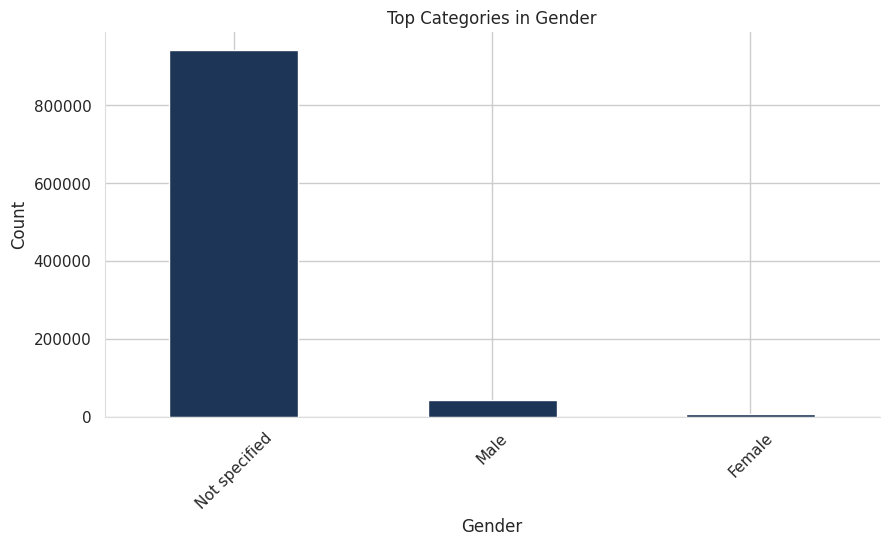

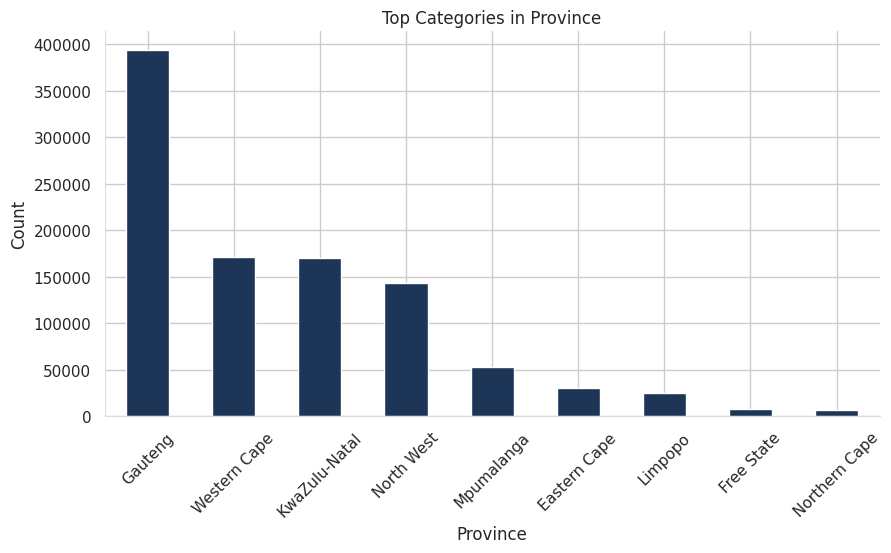

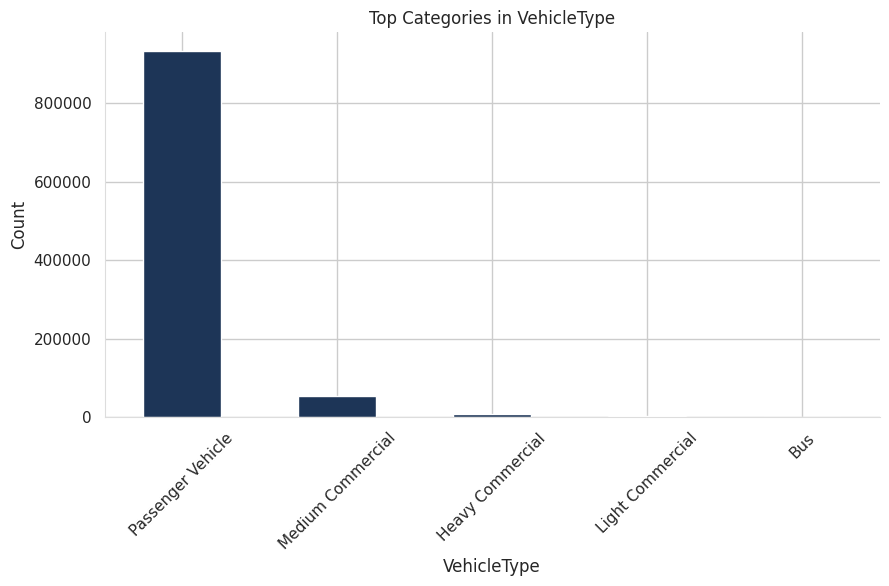

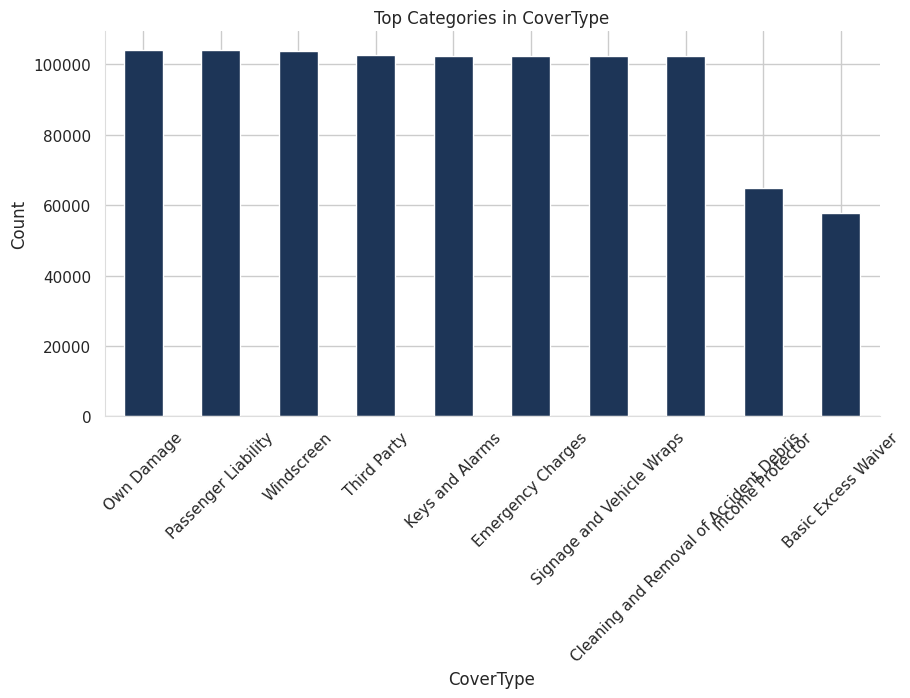

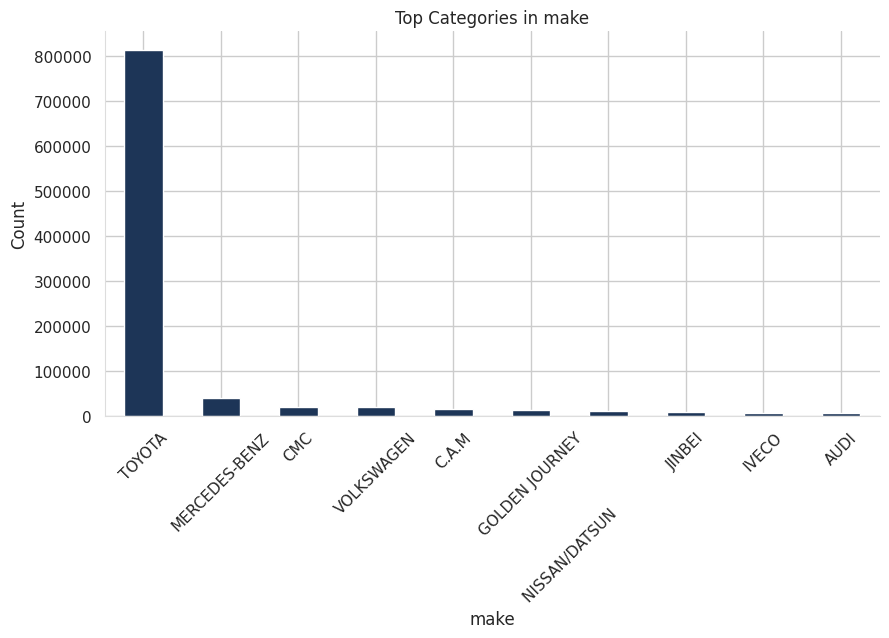

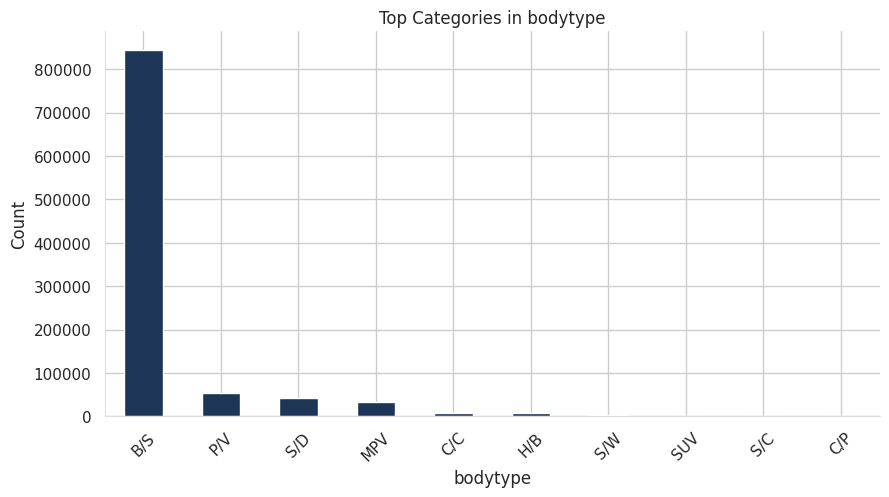

In [127]:
categorical_cols = [
    'Gender',
    'Province',
    'VehicleType',
    'CoverType',
    'make',
    'bodytype'
]
for col in categorical_cols:

    plt.figure(figsize=(10,5))

    df[col].value_counts().head(10).plot(
        kind='bar'
    )

    plt.title(f'Top Categories in {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.xticks(rotation=45)

    plt.show()

Bivariate / Multivariate Analysis

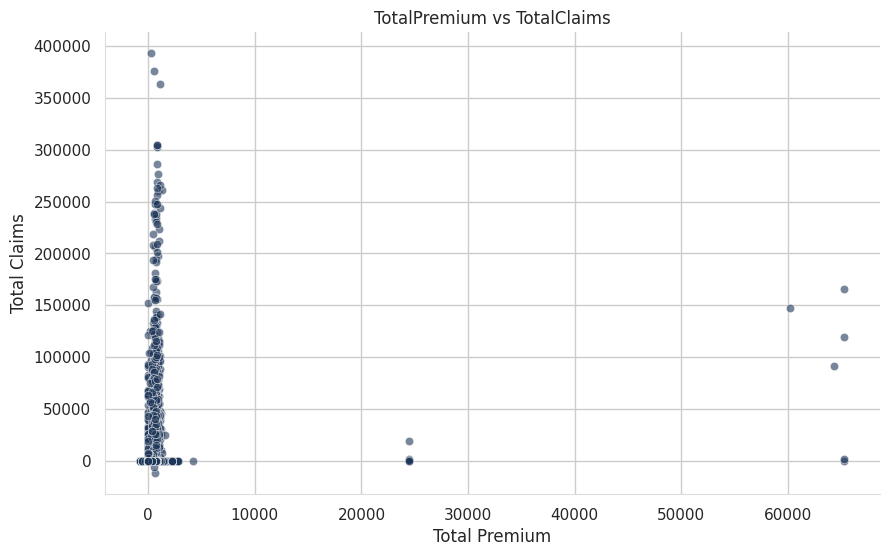

In [128]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='TotalPremium',
    y='TotalClaims',
    alpha=0.6
)

plt.title(
    'TotalPremium vs TotalClaims'
)

plt.xlabel('Total Premium')
plt.ylabel('Total Claims')

plt.show()

Relationship By Postal code

In [129]:
zipcode_analysis = df.groupby(
    'PostalCode'
)[['TotalPremium', 'TotalClaims']].mean()

print(zipcode_analysis.head())

            TotalPremium  TotalClaims
PostalCode                           
1              51.120638    57.589092
2              40.901700    41.589582
4             113.947737     0.000000
5              61.653626   207.378816
6              50.591432    19.610447


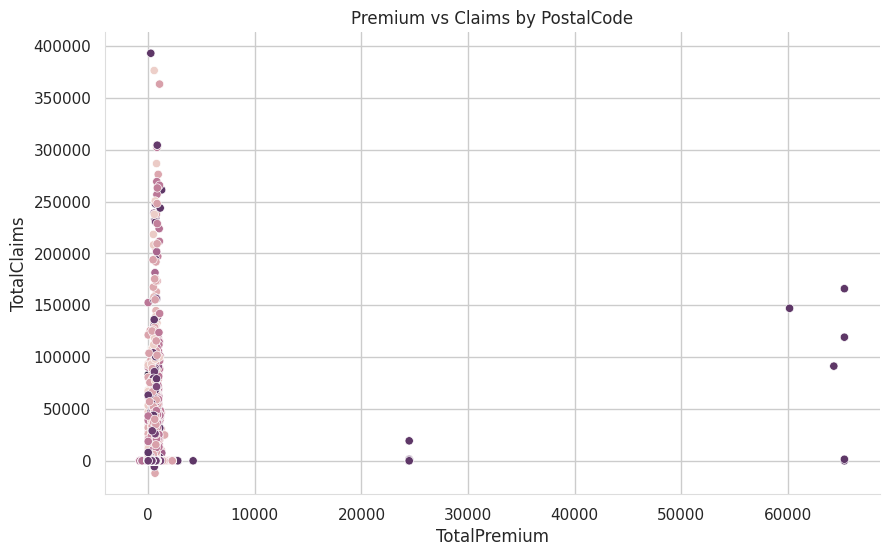

In [130]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='TotalPremium',
    y='TotalClaims',
    hue='PostalCode',
    legend=False
)

plt.title(
    'Premium vs Claims by PostalCode'
)

plt.show()

Correlation Matrix

                          TotalPremium  TotalClaims  SumInsured  \
TotalPremium                  1.000000     0.121588   -0.041174   
TotalClaims                   0.121588     1.000000   -0.005129   
SumInsured                   -0.041174    -0.005129    1.000000   
CalculatedPremiumPerTerm      0.635987     0.079787   -0.032294   
CustomValueEstimate           0.019965     0.000853   -0.000213   
CapitalOutstanding            0.016060    -0.000224   -0.002551   
kilowatts                     0.035024     0.003099   -0.002167   
cubiccapacity                 0.042554     0.001228   -0.002233   
Cylinders                     0.006826     0.000043    0.001635   
NumberOfDoors                -0.008002     0.001700   -0.000277   

                          CalculatedPremiumPerTerm  CustomValueEstimate  \
TotalPremium                              0.635987             0.019965   
TotalClaims                               0.079787             0.000853   
SumInsured                           

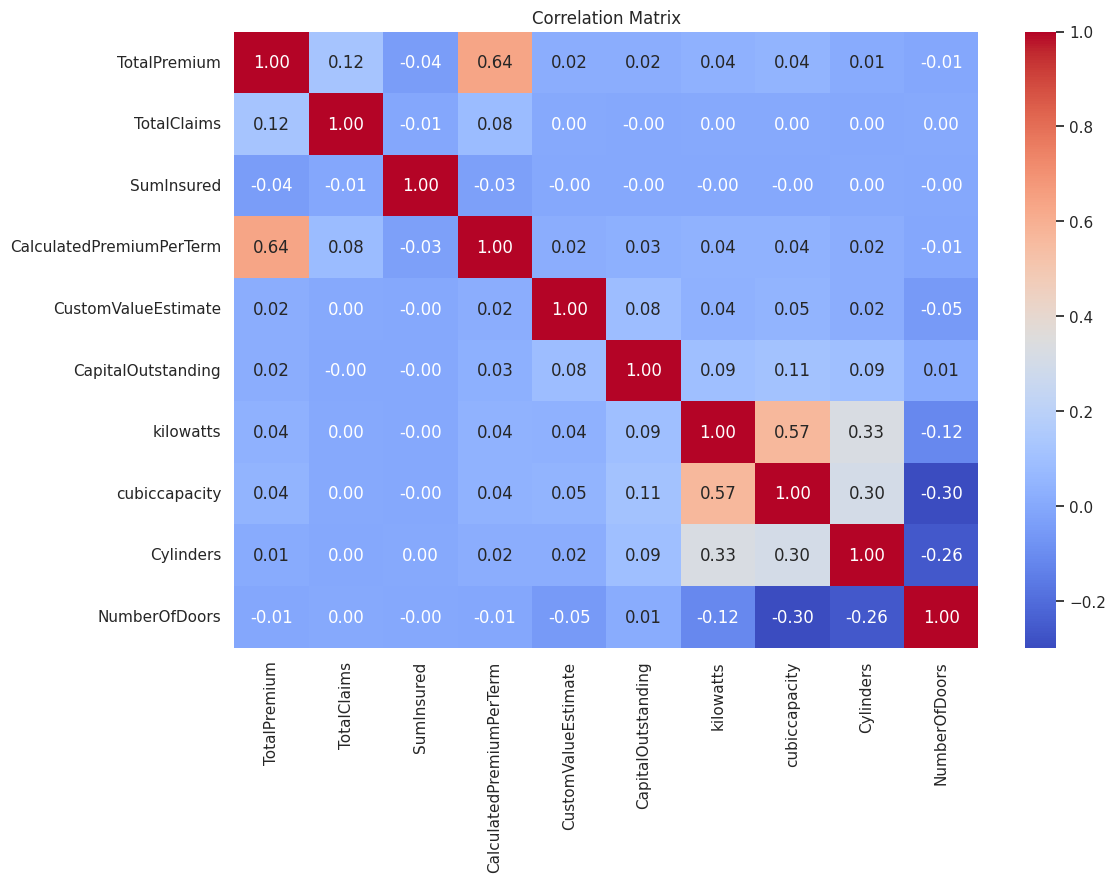

In [131]:
correlation_matrix = (
    df[numerical_cols]
    .corr()
)

print(correlation_matrix)
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

Geographic Trends

CoverType Across Province

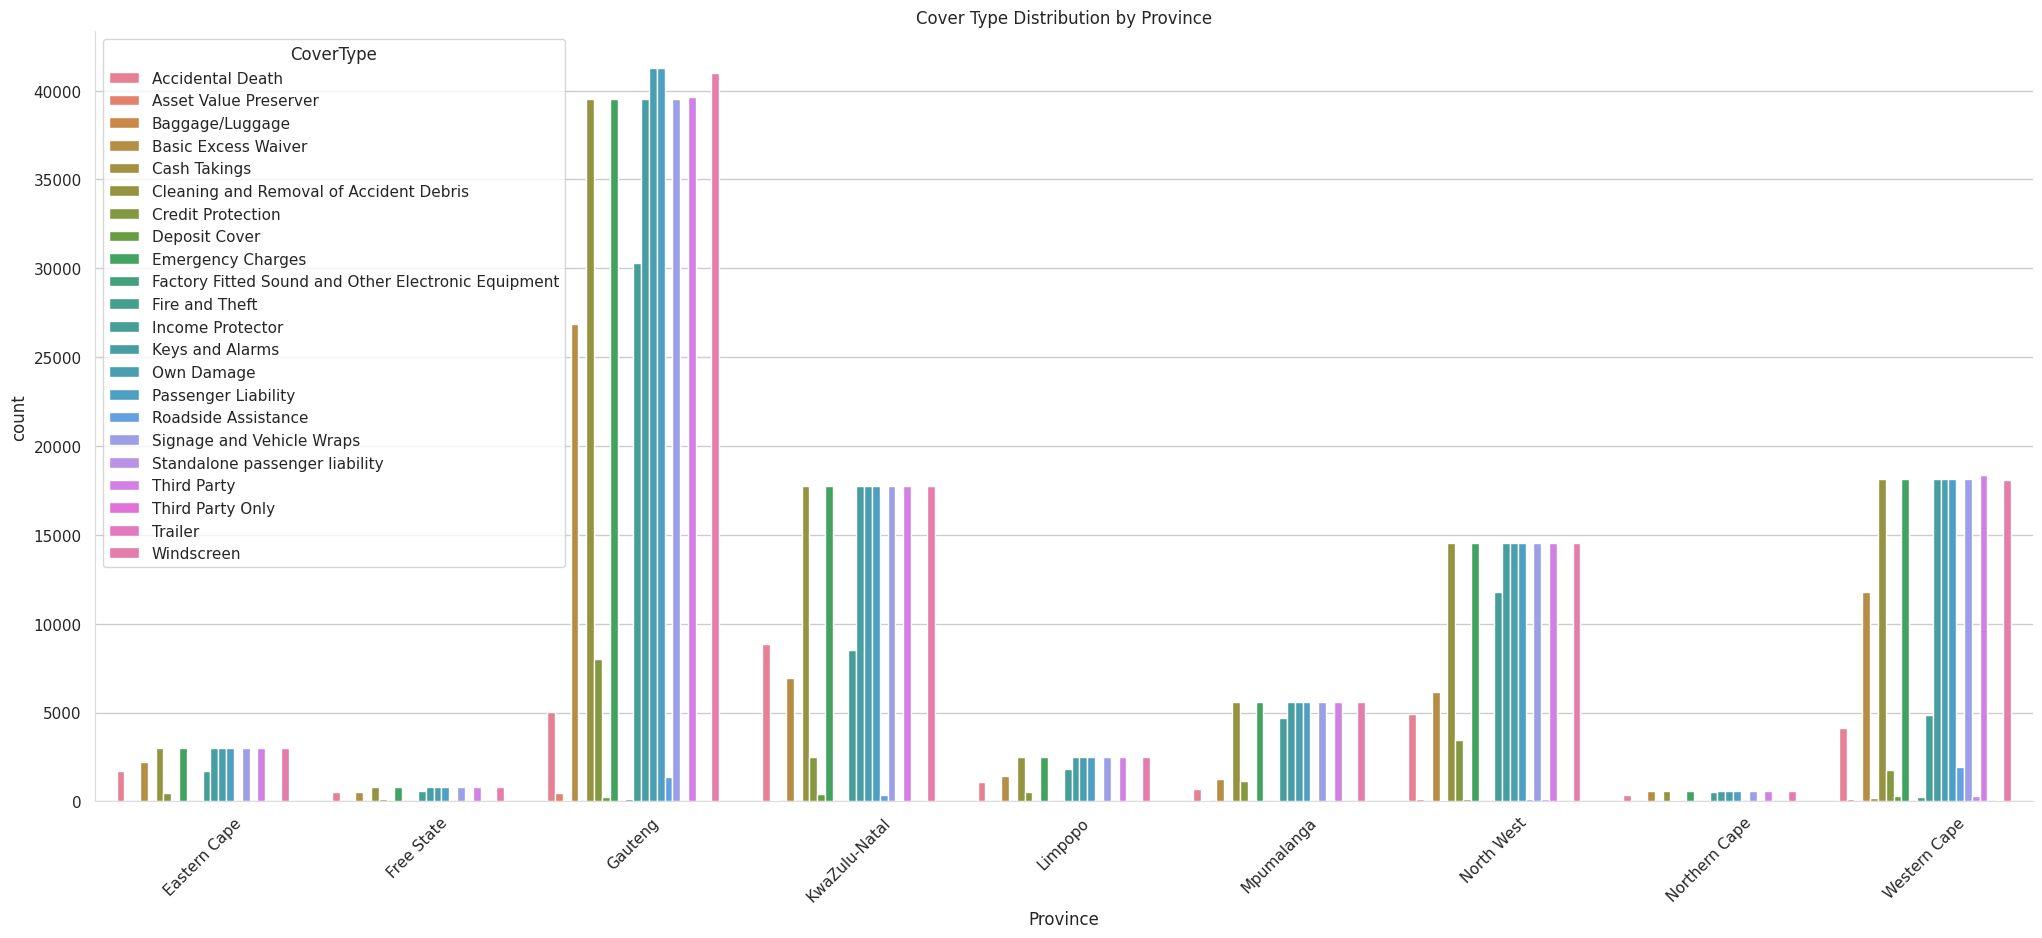

In [132]:
plt.figure(figsize=(25,10))

sns.countplot(
    data=df,
    x='Province',
    hue='CoverType'
)

plt.title(
    'Cover Type Distribution by Province'
)

plt.xticks(rotation=45)

plt.show()

Average Premium by Province

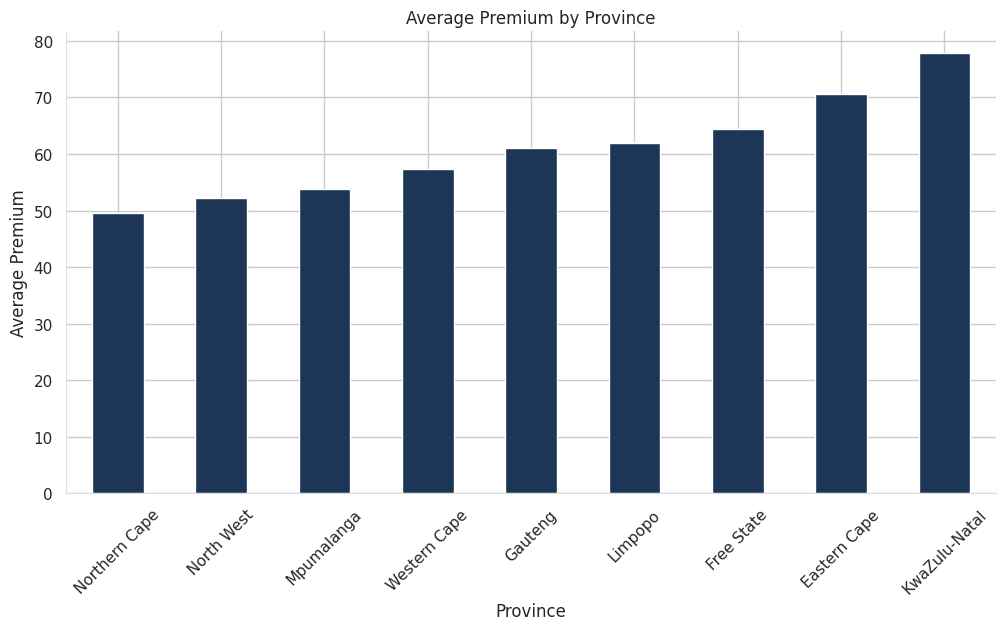

In [133]:
province_premium = df.groupby(
    'Province'
)['TotalPremium'].mean().sort_values()

plt.figure(figsize=(12,6))

province_premium.plot(kind='bar')

plt.title(
    'Average Premium by Province'
)

plt.ylabel('Average Premium')

plt.xticks(rotation=45)

plt.show()

Auto Make Distribution Across Provinces

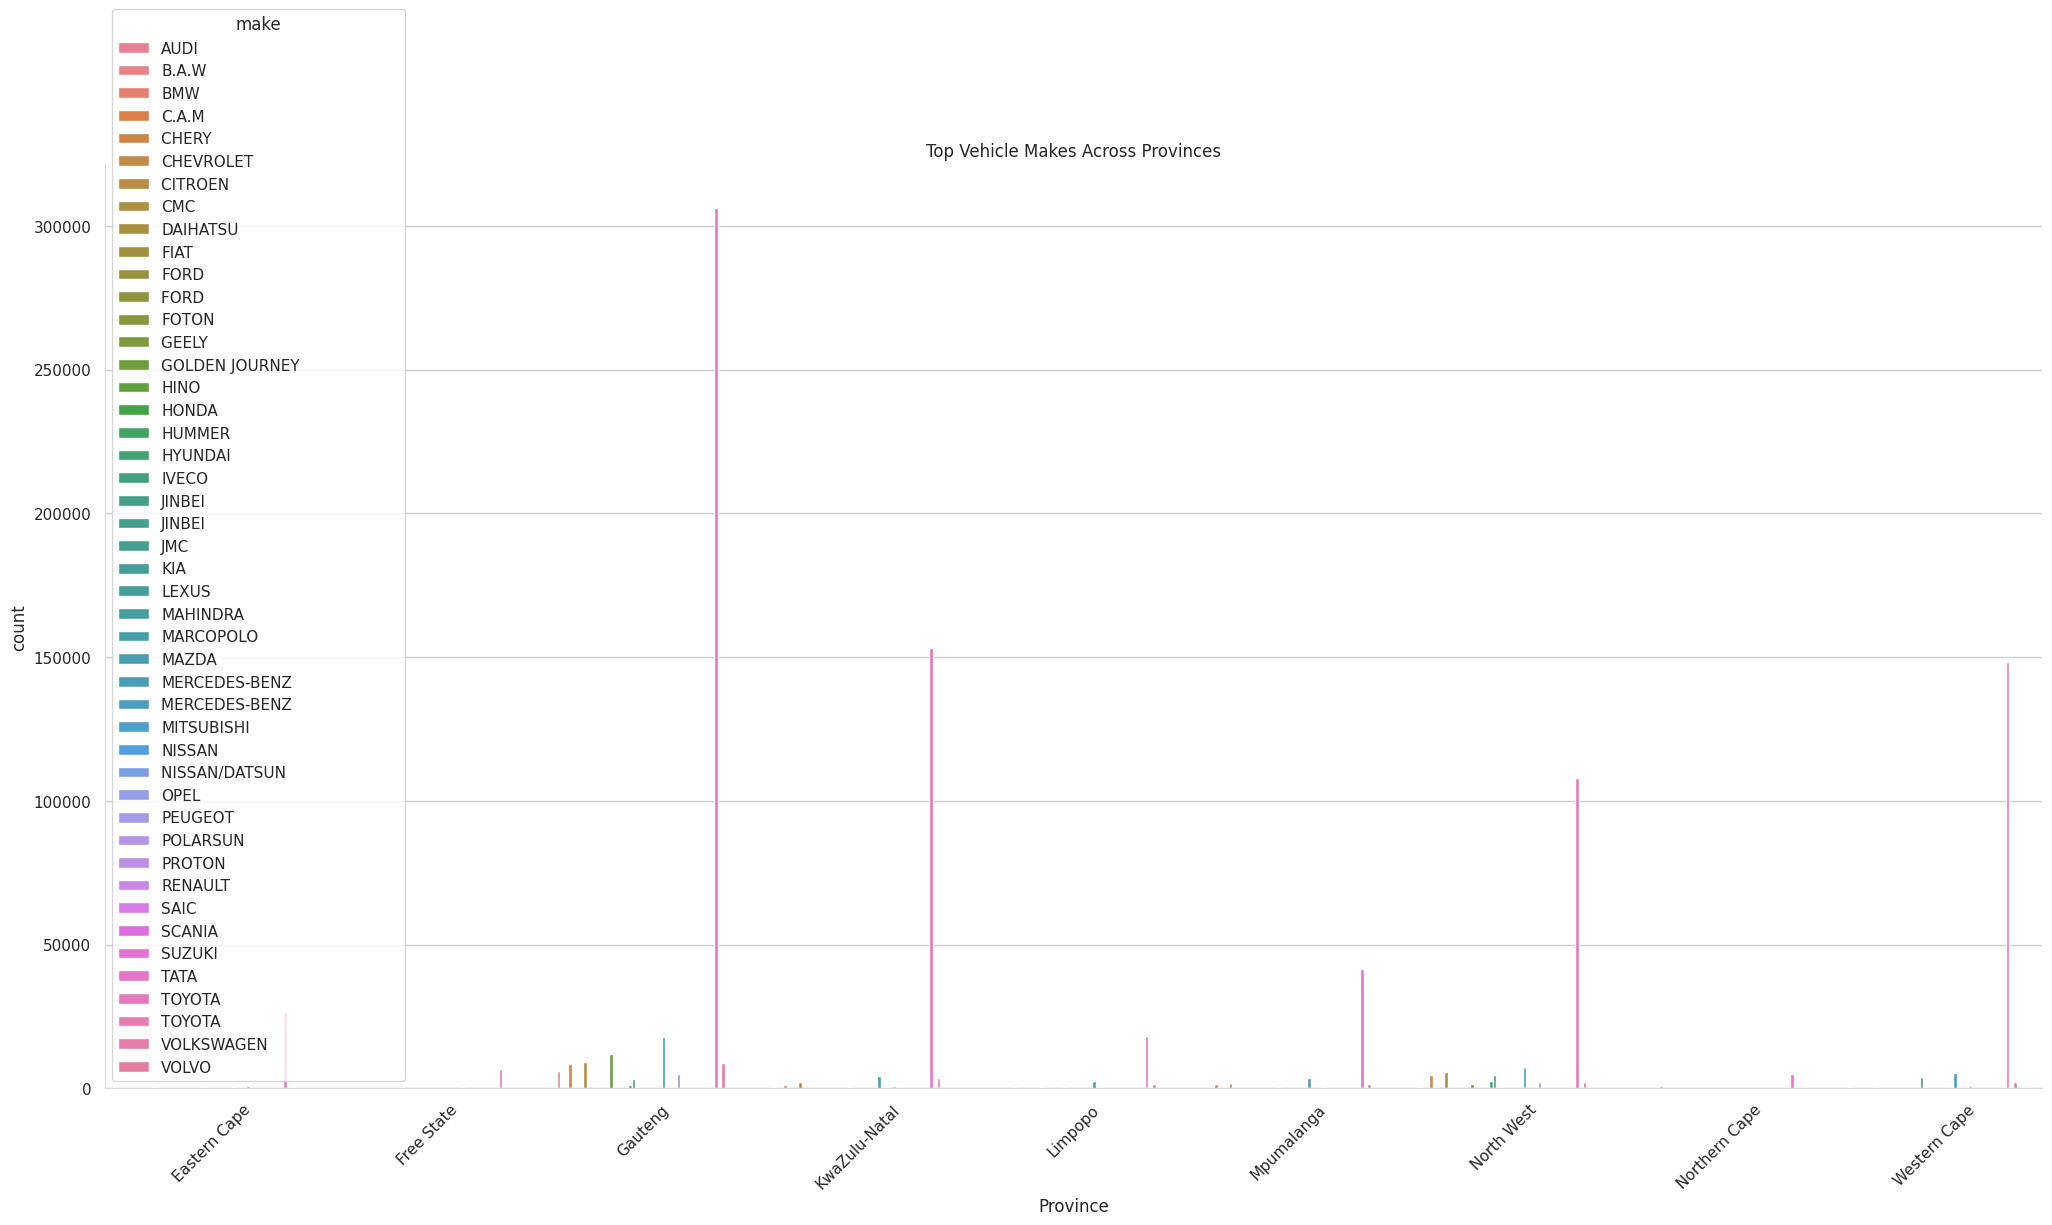

In [134]:
top_makes = df['make'].value_counts().head(10).index

filtered_df = df[
    df['make'].isin(top_makes)
]

plt.figure(figsize=(25, 12))

sns.countplot(
    data=filtered_df,
    x='Province',
    hue='make'
)

plt.title(
    'Top Vehicle Makes Across Provinces'
)

plt.xticks(rotation=45)

plt.show()

Outlier Detection

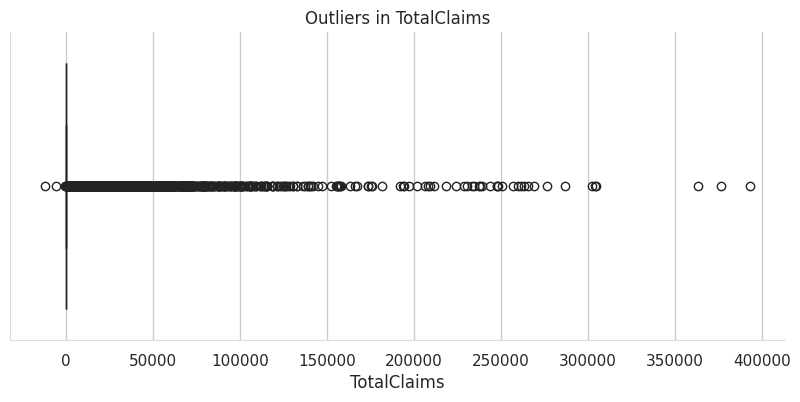

In [135]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['TotalClaims']
)

plt.title(
    'Outliers in TotalClaims'
)

plt.show()

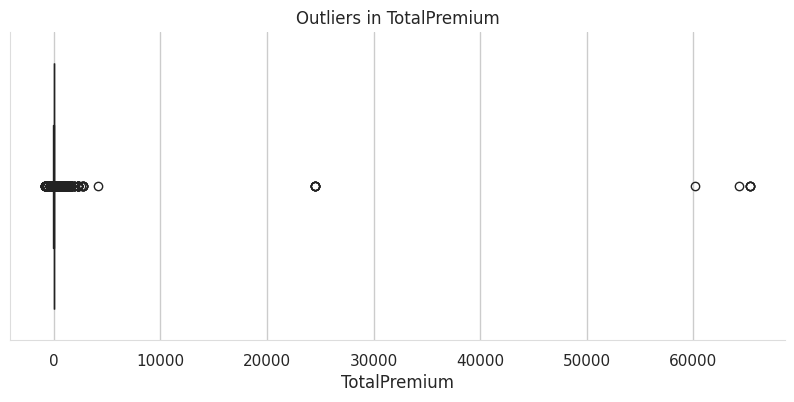

In [136]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['TotalPremium']
)

plt.title(
    'Outliers in TotalPremium'
)

plt.show()

Detect Outliers Using IQR

In [137]:
Q1 = df['TotalClaims'].quantile(0.25)
Q3 = df['TotalClaims'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['TotalClaims'] < lower_bound) |
    (df['TotalClaims'] > upper_bound)
]

print(
    "Number of Outliers:",
    outliers.shape[0]
)

Number of Outliers: 2793


## 2. Descriptive Analytics: "What Happened?"
Descriptive analytics is the foundation of data analysis, providing an aggregate view of historical events. For AlphaCare Insurance Solutions (ACIS), this means understanding past claim frequencies, average claim amounts, demographics, and overall loss ratios.

### Key Business Questions:
- What is our overall claim rate and annual loss ratio?
- How are claims distributed geographically and across vehicle types?

Data Summarization: overall_loss_ratio

In [ ]:
overall_loss_ratio = (
    df["TotalClaims"].sum() /
    df["TotalPremium"].sum()
)

print(f"Overall Loss Ratio: {overall_loss_ratio:.2%}")

Overall Loss Ratio: 104.77%


Loss Ratio by Province

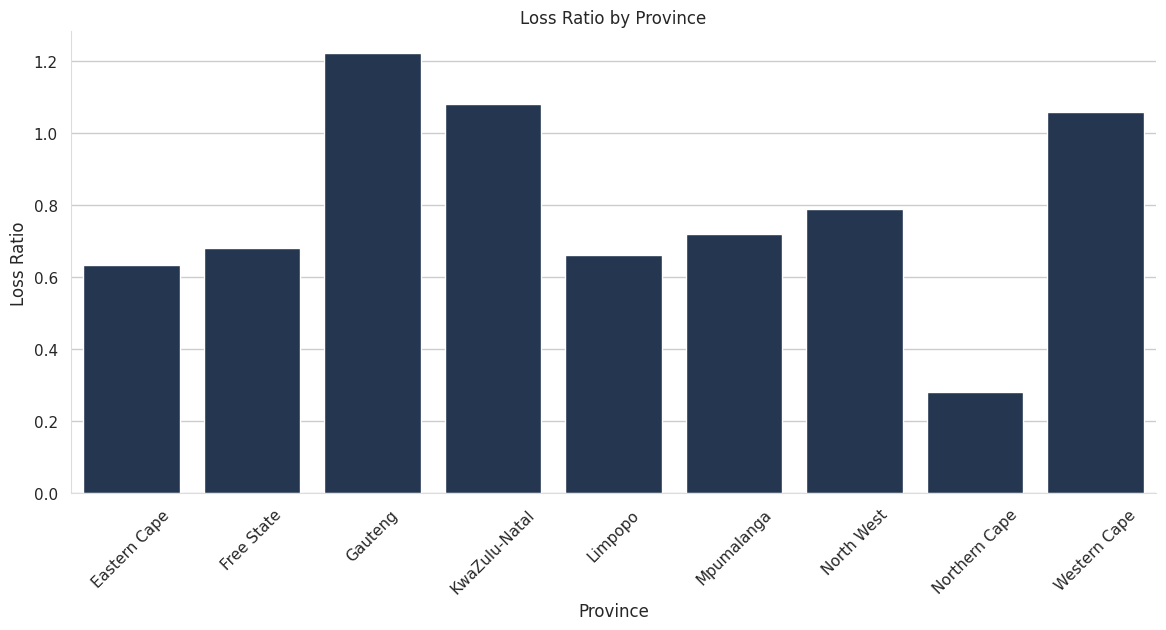

In [141]:
province_lr = (
    df.groupby("Province")[["TotalClaims", "TotalPremium"]]
      .sum()
)

province_lr["LossRatio"] = (
    province_lr["TotalClaims"] /
    province_lr["TotalPremium"]
)

province_lr = province_lr.sort_values("LossRatio", ascending=False)
province_lr

plt.figure(figsize=(14,6))
sns.barplot(
    x=province_lr.index,
    y=province_lr["LossRatio"]
)
plt.xticks(rotation=45)
plt.title("Loss Ratio by Province")
plt.ylabel("Loss Ratio")
plt.show()

Loss Ratio by Vehicle Type

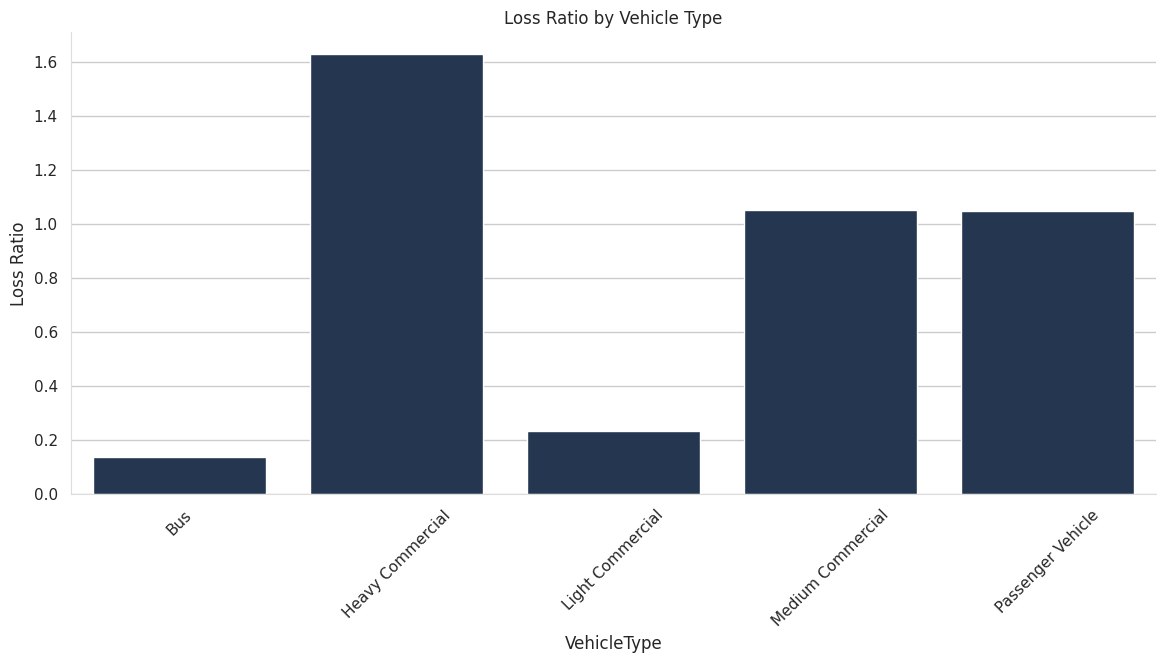

In [143]:
vehicle_lr = (
    df.groupby("VehicleType")[["TotalClaims", "TotalPremium"]]
      .sum()
)

vehicle_lr["LossRatio"] = (
    vehicle_lr["TotalClaims"] /
    vehicle_lr["TotalPremium"]
)

vehicle_lr = vehicle_lr.sort_values("LossRatio", ascending=False)
vehicle_lr

plt.figure(figsize=(14,6))
sns.barplot(
    x=vehicle_lr.index,
    y=vehicle_lr["LossRatio"]
)
plt.xticks(rotation=45)
plt.title("Loss Ratio by Vehicle Type")
plt.ylabel("Loss Ratio")
plt.show()

Loss Ratio by Gender

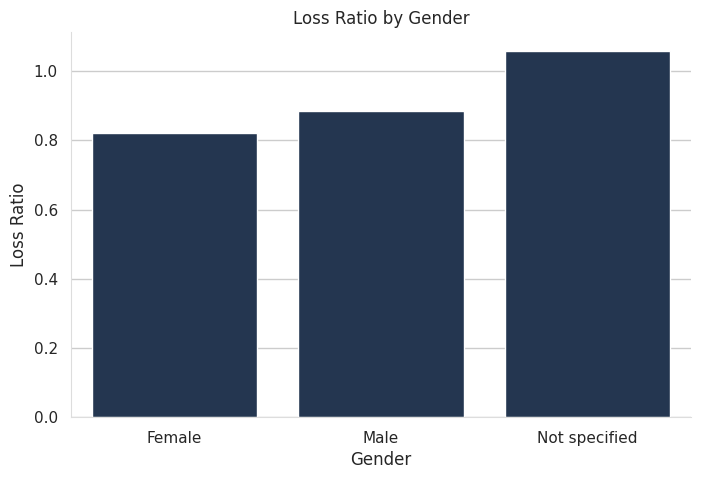

In [145]:
gender_lr = (
    df.groupby("Gender")[["TotalClaims", "TotalPremium"]]
      .sum()
)

gender_lr["LossRatio"] = (
    gender_lr["TotalClaims"] /
    gender_lr["TotalPremium"]
)

gender_lr

plt.figure(figsize=(8,5))
sns.barplot(
    x=gender_lr.index,
    y=gender_lr["LossRatio"]
)
plt.title("Loss Ratio by Gender")
plt.ylabel("Loss Ratio")
plt.show()

Distribution Analysis of Financial Variables

Distribution of Total Claims

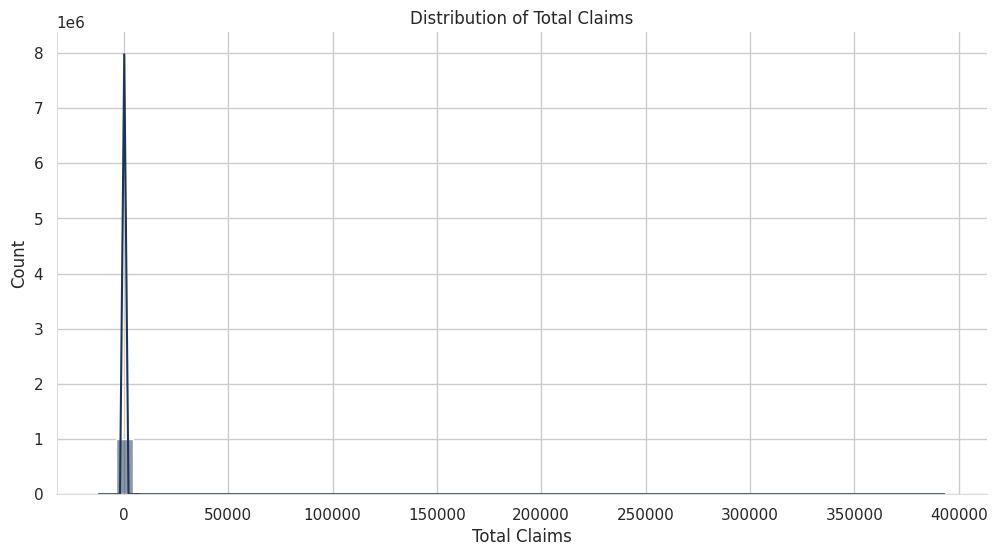

In [146]:
plt.figure(figsize=(12,6))
sns.histplot(df["TotalClaims"], bins=50, kde=True)
plt.title("Distribution of Total Claims")
plt.xlabel("Total Claims")
plt.show()

Distribution of Custom Value Estimate

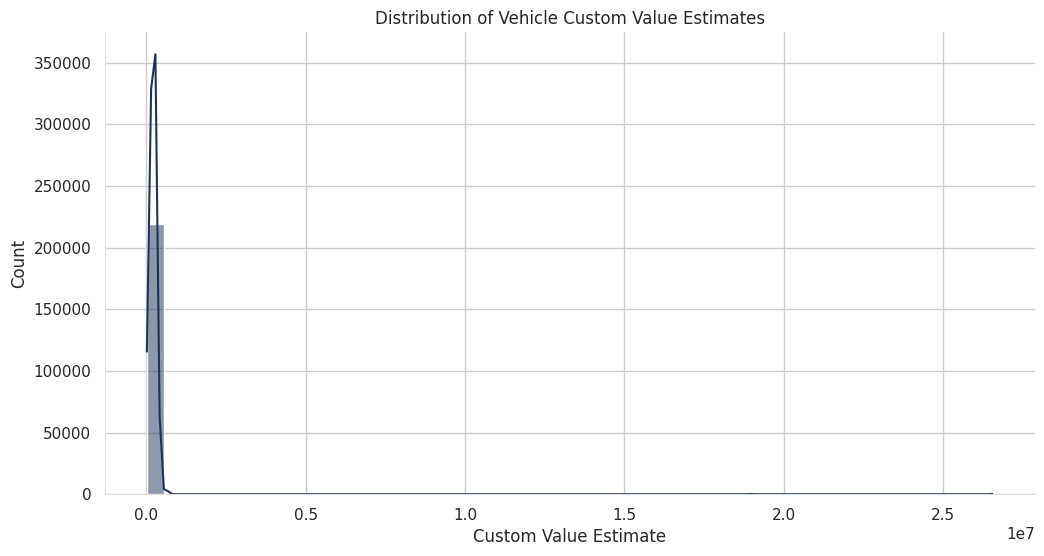

In [147]:
plt.figure(figsize=(12,6))
sns.histplot(df["CustomValueEstimate"].dropna(), bins=50, kde=True)
plt.title("Distribution of Vehicle Custom Value Estimates")
plt.xlabel("Custom Value Estimate")
plt.show()

Outlier Detection

Boxplot for Total Claims

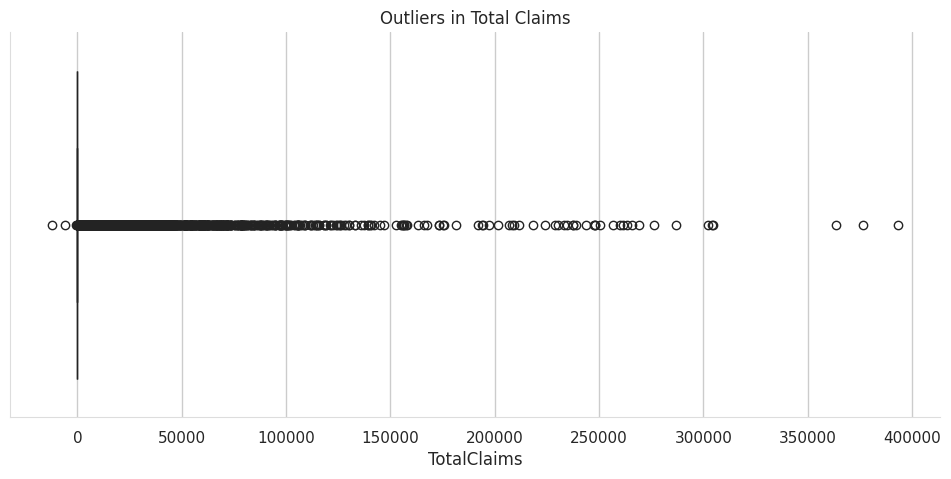

In [148]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df["TotalClaims"])
plt.title("Outliers in Total Claims")
plt.show()

Boxplot for Custom Value Estimate

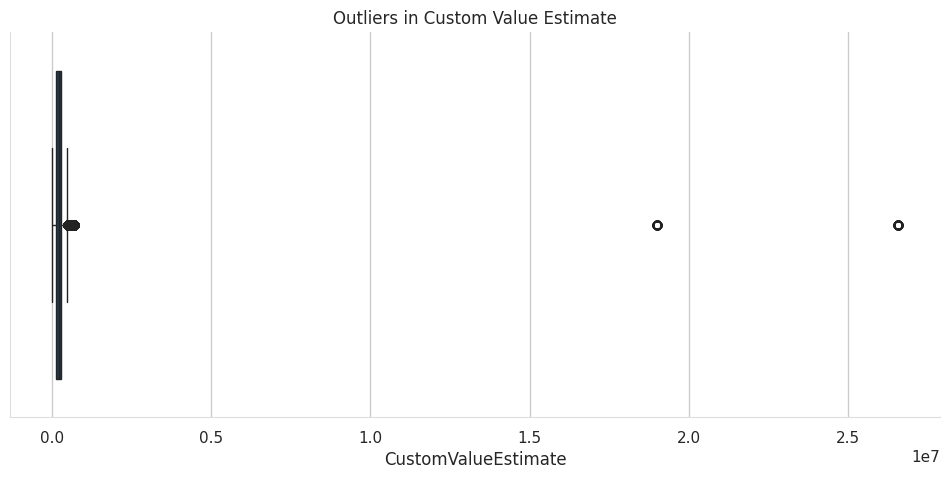

In [149]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df["CustomValueEstimate"])
plt.title("Outliers in Custom Value Estimate")
plt.show()

IQR-Based Outlier Detection

In [150]:
Q1 = df["TotalClaims"].quantile(0.25)
Q3 = df["TotalClaims"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = df[df["TotalClaims"] > upper_bound]

print("Number of Claim Outliers:", outliers.shape[0])
outliers[["TotalClaims", "make", "Model"]].head()

Number of Claim Outliers: 2788


,TotalClaims,make,Model
203,2294.096491,AUDI,A4 1.8T ATTRACTION (B8)
284,2040.473684,FORD,TERRITORY 4.0i GHIA AWD A/T
1560,46492.211754,BMW,316i A/T (F30)
1779,26516.859649,VOLKSWAGEN,CRAFTER 50 HR 80 F/C P/V
1943,6140.350877,BMW,316i A/T (F30)


Temporal Trend Analysis

In [151]:
monthly = (
    df.groupby(df["TransactionMonth"].dt.to_period("M"))
      .agg({
          "TotalClaims": "sum",
          "TotalPremium": "sum",
          "PolicyID": "count"
      })
)

monthly.index = monthly.index.astype(str)
monthly.rename(columns={"PolicyID": "PolicyCount"}, inplace=True)

monthly.head()

,TotalClaims,TotalPremium,PolicyCount
TransactionMonth,,,
2013-10,0.000000,371.063512,45
2013-11,50585.078947,21307.467009,1196
2013-12,9283.385965,42484.748888,1495
2014-01,12436.859649,54085.196865,1827
2014-02,62989.307018,60788.436470,2062


Claim Severity Over Time

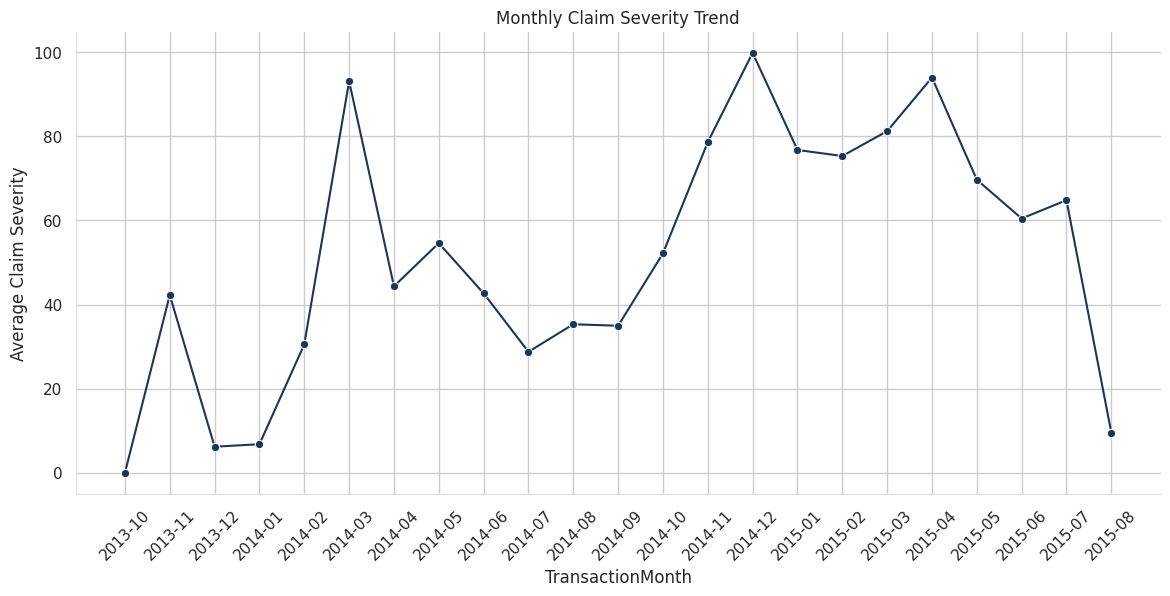

In [152]:
monthly["ClaimSeverity"] = (
    monthly["TotalClaims"] /
    monthly["PolicyCount"]
)

plt.figure(figsize=(14,6))
sns.lineplot(
    x=monthly.index,
    y=monthly["ClaimSeverity"],
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Claim Severity Trend")
plt.ylabel("Average Claim Severity")
plt.show()

Claim Frequency Trend

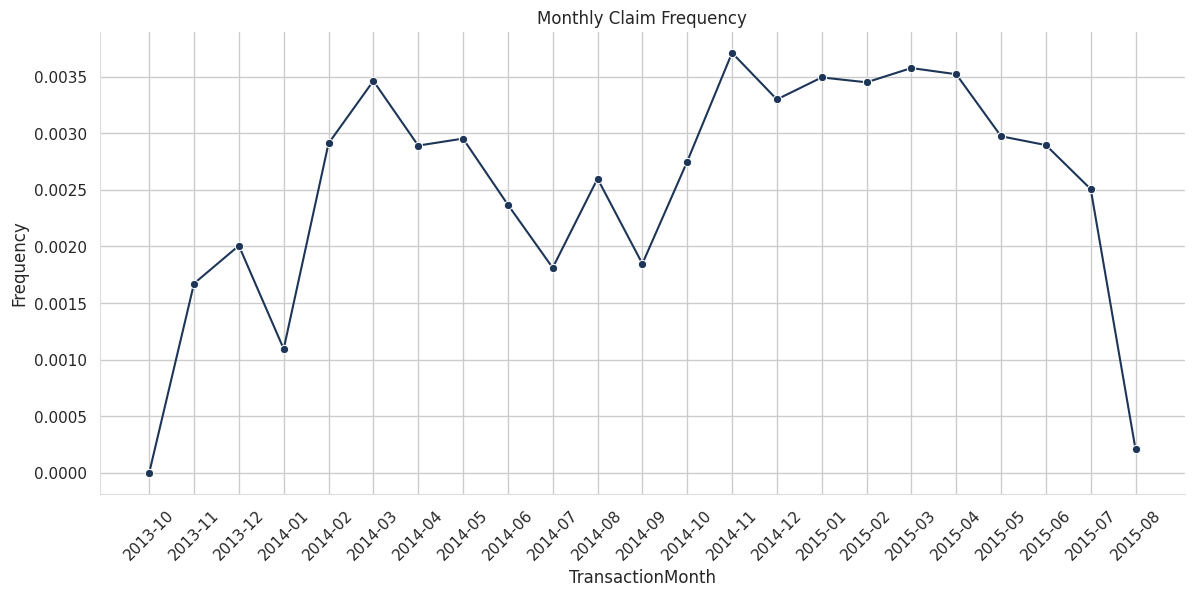

In [153]:
claim_frequency = (
    df.groupby(df["TransactionMonth"].dt.to_period("M"))
      .apply(lambda x: (x["TotalClaims"] > 0).mean())
)

claim_frequency.index = claim_frequency.index.astype(str)

plt.figure(figsize=(14,6))
sns.lineplot(
    x=claim_frequency.index,
    y=claim_frequency.values,
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Claim Frequency")
plt.ylabel("Frequency")
plt.show()

Vehicle Make & Model Analysis

Highest Claim Amounts by Vehicle Make

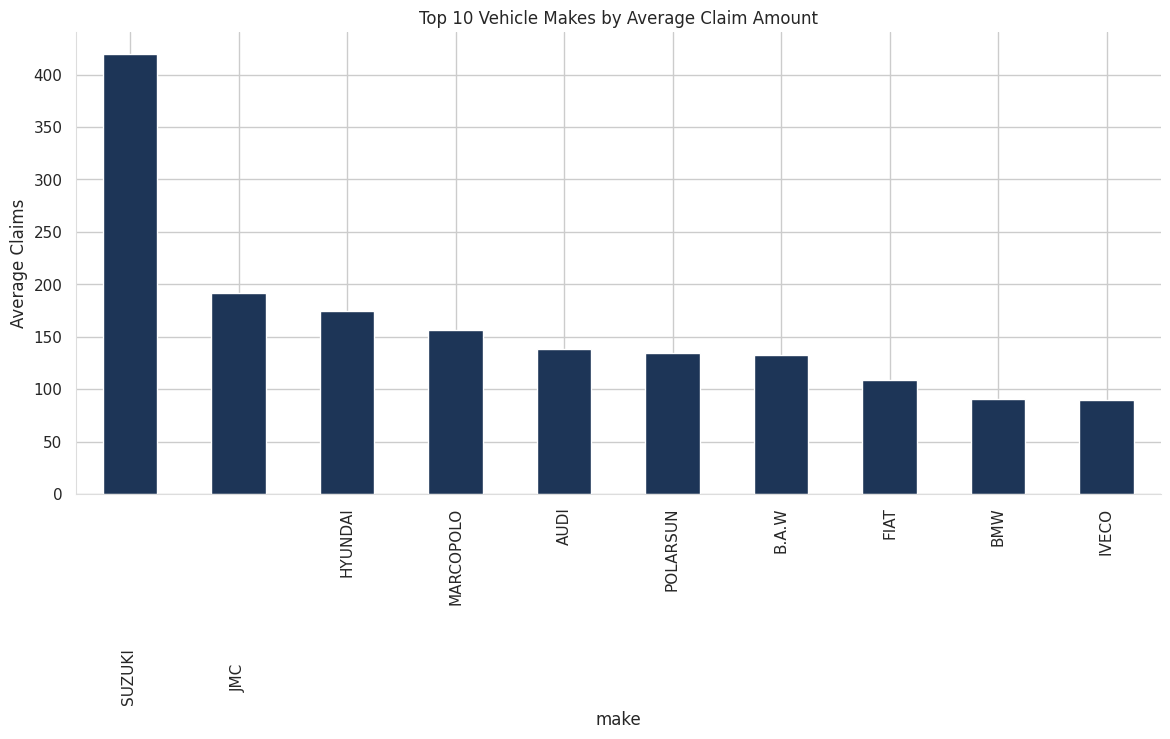

In [154]:
make_claims = (
    df.groupby("make")["TotalClaims"]
      .mean()
      .sort_values(ascending=False)
)

make_claims.head(10)
plt.figure(figsize=(14,6))
make_claims.head(10).plot(kind="bar")
plt.title("Top 10 Vehicle Makes by Average Claim Amount")
plt.ylabel("Average Claims")
plt.show()

Highest Claim Amounts by Vehicle Make

In [155]:
make_claims.tail(10)

make
HINO                                   0.0
JINBEI                                 0.0
LEXUS                                  0.0
PROTON                                 0.0
PEUGEOT                                0.0
OPEL                                   0.0
RENAULT                                0.0
SCANIA                                 0.0
TATA                                   0.0
VOLVO                                  0.0
Name: TotalClaims, dtype: float64

Highest Claim Amounts by Vehicle Model

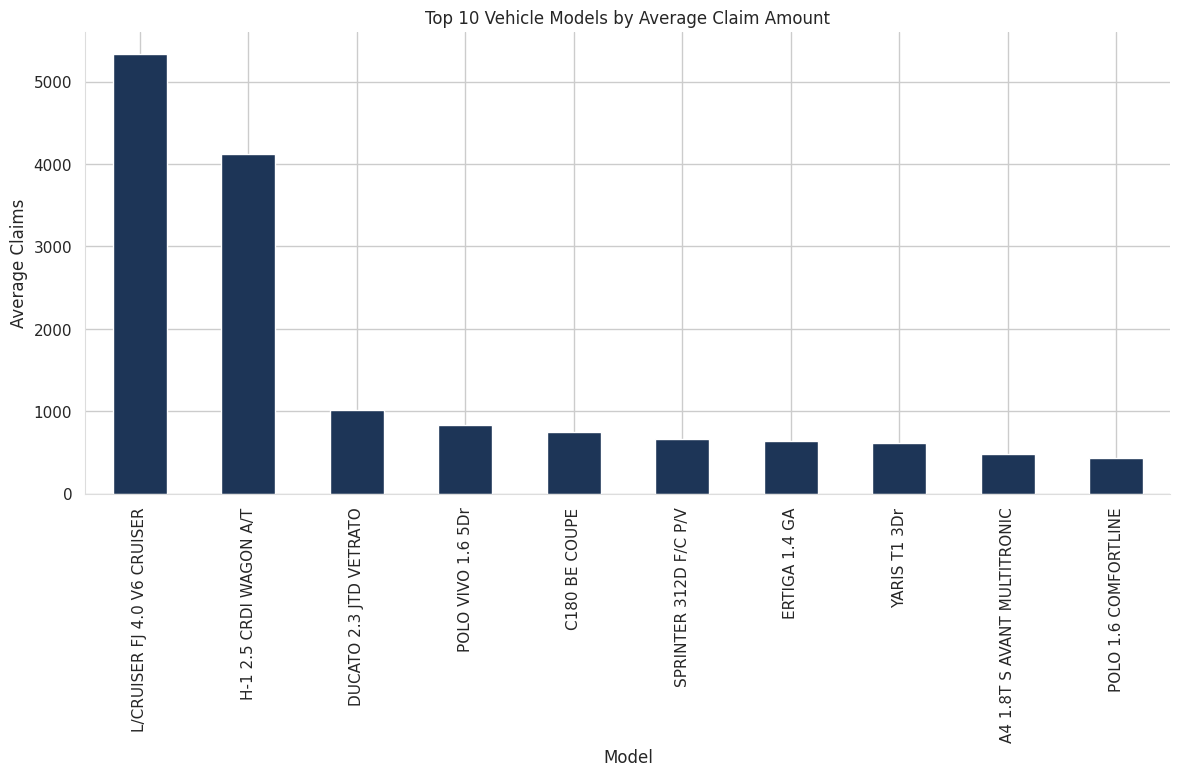

In [156]:
model_claims = (
    df.groupby("Model")["TotalClaims"]
      .mean()
      .sort_values(ascending=False)
)

model_claims.head(10)

plt.figure(figsize=(14,6))
model_claims.head(10).plot(kind="bar")
plt.title("Top 10 Vehicle Models by Average Claim Amount")
plt.ylabel("Average Claims")
plt.show()

Creative & Insightful Visualizations

Plot 1 — Province Risk Heatmap

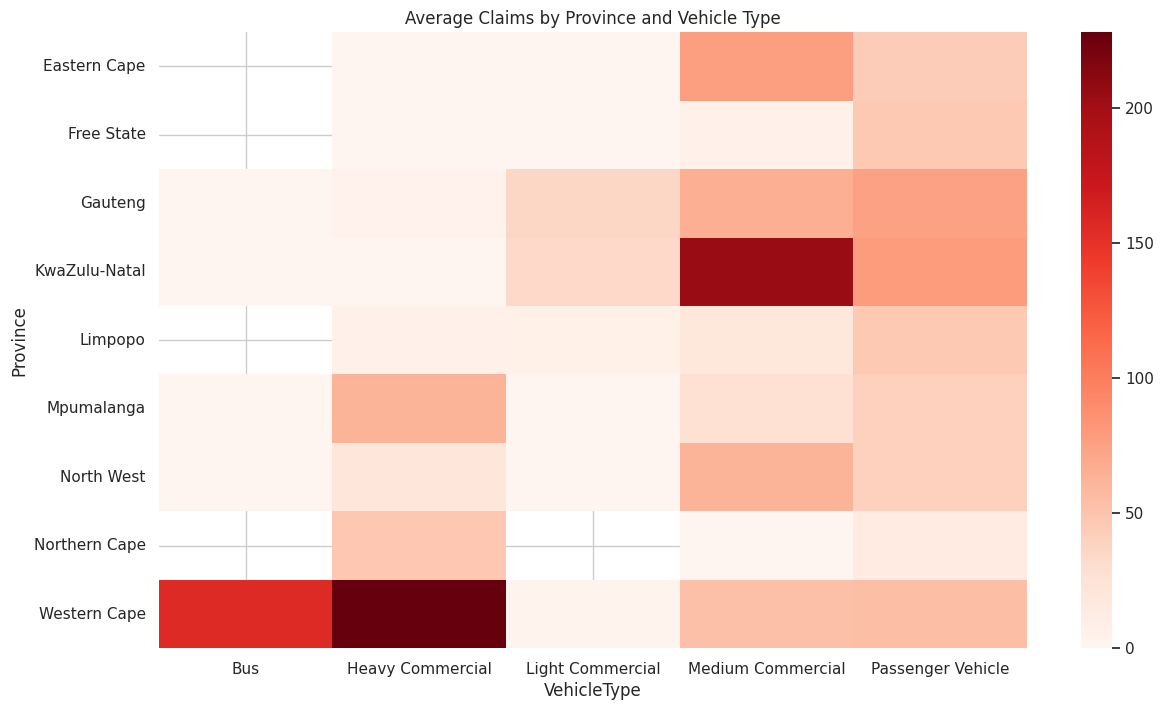

In [157]:
pivot = df.pivot_table(
    values="TotalClaims",
    index="Province",
    columns="VehicleType",
    aggfunc="mean"
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap="Reds", annot=False)
plt.title("Average Claims by Province and Vehicle Type")
plt.show()

Plot 2 — Bubble Plot of Premium vs Claims

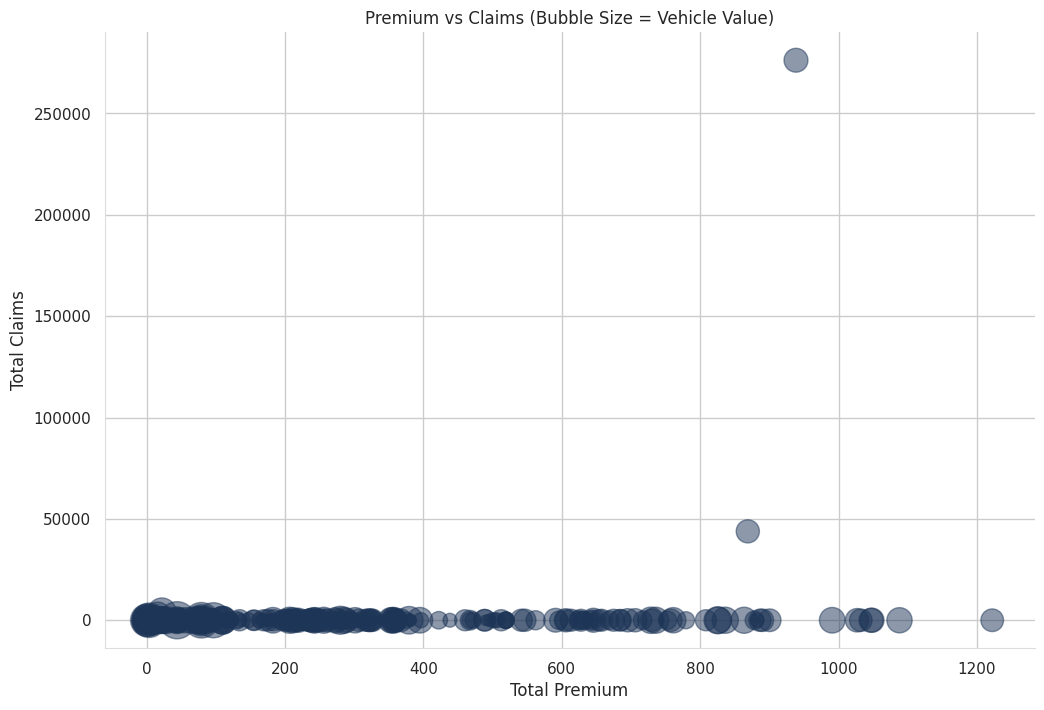

In [158]:
sample_df = df.sample(min(5000, len(df)), random_state=42)

plt.figure(figsize=(12,8))

plt.scatter(
    sample_df["TotalPremium"],
    sample_df["TotalClaims"],
    s=sample_df["CustomValueEstimate"] / 1000,
    alpha=0.5
)

plt.xlabel("Total Premium")
plt.ylabel("Total Claims")
plt.title("Premium vs Claims (Bubble Size = Vehicle Value)")
plt.show()

Plot 3 — Monthly Claims & Premium Trend

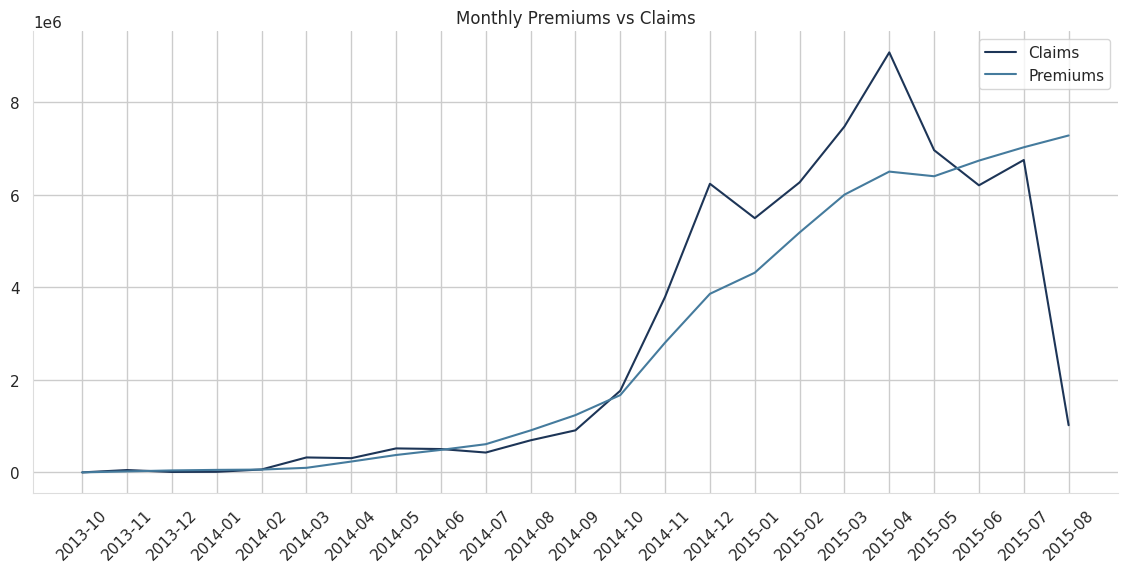

In [159]:
plt.figure(figsize=(14,6))

plt.plot(monthly.index, monthly["TotalClaims"], label="Claims")
plt.plot(monthly.index, monthly["TotalPremium"], label="Premiums")

plt.xticks(rotation=45)
plt.legend()
plt.title("Monthly Premiums vs Claims")
plt.show()